# 03 : LGD, EAD et Perte Attendue (Expected Loss)
Projet : Credit Risk Scoring (Lending Club)

## Pourquoi ce notebook est le cœur du projet

Le notebook 02 a répondu à une seule question : **"ce prêt va-t-il faire défaut ?"**
(probabilité de défaut, PD). Mais pour une banque, savoir *qu'un client risque
de ne pas rembourser* ne suffit pas, ce qui compte financièrement, c'est
**combien d'argent elle va réellement perdre**. Un client à haut risque sur un
petit prêt peut coûter moins cher qu'un client à risque modéré sur un gros prêt.

C'est exactement ce que mesure la **perte attendue (Expected Loss, EL)**, la
métrique que toutes les banques utilisent pour provisionner leurs pertes futures
(exigée par les régulateurs sous le nom de "provisions IFRS 9" ou "Bâle III").
Elle se décompose en trois briques :

| Sigle | Nom complet | Question à laquelle ça répond | Analogie |
|---|---|---|---|
| **PD** | Probability of Default | Quelle est la probabilité que ce client ne rembourse pas ? | La probabilité qu'il pleuve demain |
| **LGD** | Loss Given Default | S'il ne rembourse pas, quelle proportion de la somme prêtée est réellement perdue ? | S'il pleut, quelle quantité d'eau tombe réellement (une averse ou un déluge) |
| **EAD** | Exposure At Default | Quel montant est exposé au risque au moment du défaut ? | La taille du terrain exposé à la pluie |

La formule qui les relie est simple et centrale dans tout le secteur bancaire :


**Exemple concret** : un prêt de 10 000 € avec une PD de 20%, une LGD de 40% et
une EAD de 10 000 € (le prêt n'a pas encore été remboursé) donne une perte
attendue de : 0,20 × 0,40 × 10 000 = **800 €**. C'est le montant que la banque
doit mettre de côté (provisionner) pour ce prêt, en moyenne, même si dans les
faits ce prêt spécifique remboursera intégralement ou perdra 100%, c'est une
espérance statistique sur un grand nombre de prêts similaires, pas une
prédiction individuelle certaine.

## Ce qui ai fait dans ce notebook
1. Calculer la LGD réellement observée sur les prêts historiques en défaut  
2. Modéliser la LGD pour pouvoir l'appliquer à de nouveaux prêts  
3. Estimer l'EAD  
4. Calculer la perte attendue sur l'ensemble du portefeuille test, et vérifier
   qu'elle colle à la perte réellement observée (backtesting)

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from src.data_prep import DEFAULT_STATUSES

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

## 1. Chargement des données

Le notebook 02 a sauvegardé `test_with_pd.parquet` (jeu de test + probabilité
de défaut prédite `pd_pred`), mais ce fichier ne contient plus les colonnes
nécessaires au calcul de la LGD (`recoveries`, `total_pymnt`, `total_rec_prncp`), elles avaient été volontairement exclues du jeu de features PD pour éviter
tout data leakage (notebook 01, section 3).

On recharge donc le fichier filtré complet (`accepted_filtered_2007_2017.parquet`),
qui contient encore ces colonnes, on reconstruit le même sous-ensemble "test"
(prêts émis en 2017, comme au notebook 01), puis on y rattache les prédictions
`pd_pred`.

**Point de vigilance méthodologique** : comme il n'y a pas d'identifiant unique
de prêt dans nos colonnes chargées, ce rattachement se fait par position (les
deux jeux de données ont été construits par les mêmes filtres, dans le même
ordre, sans tri intermédiaire l'ordre des lignes est donc préservé). On
valide cette hypothèse juste après avec une vérification croisée.

In [2]:
df_full = pd.read_parquet("../data/processed/accepted_filtered_2007_2017.parquet")
df_full["issue_d"] = pd.to_datetime(df_full["issue_d"])

test_full = df_full[df_full["issue_d"].dt.year == 2017].reset_index(drop=True)
print(f"Test complet (avec colonnes de perte) : {test_full.shape[0]:,} lignes".replace(",", " "))

test_with_pd = pd.read_parquet("../data/processed/test_with_pd.parquet").reset_index(drop=True)
print(f"Test avec PD prédite : {test_with_pd.shape[0]:,} lignes".replace(",", " "))

assert test_full.shape[0] == test_with_pd.shape[0], "Les deux jeux n'ont pas la même taille !"

Test complet (avec colonnes de perte) : 169 321 lignes
Test avec PD prédite : 169 321 lignes


In [3]:
# Validation croisée du rattachement par position : loan_amnt et default
# doivent être strictement identiques ligne à ligne entre les deux sources
check_amnt = (test_full["loan_amnt"].values == test_with_pd["loan_amnt"].values).mean()
check_default = (test_full["default"].values == test_with_pd["default"].values).mean()

print(f"Correspondance loan_amnt  : {check_amnt:.4%}")
print(f"Correspondance default    : {check_default:.4%}")

if check_amnt < 1.0 or check_default < 1.0:
    raise ValueError("Le rattachement par position n'est pas fiable, à investiguer avant de continuer.")

test = test_full.copy()
test["pd_pred"] = test_with_pd["pd_pred"].values
print("\nRattachement validé, colonne pd_pred ajoutée.")

Correspondance loan_amnt  : 100.0000%
Correspondance default    : 100.0000%

Rattachement validé, colonne pd_pred ajoutée.


In [4]:
test.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_rec_prncp,recoveries,collection_recovery_fee,default,pd_pred
0,35000.0,35000.0,60 months,12.62,789.570007,C,C1,10+ years,MORTGAGE,85000.0,Source Verified,2017-09-01,Fully Paid,house,12.140000,0.0,Apr-1998,680.0,684.0,0.0,7.0,1.0,6029.0,30.600000,17.0,39723.460938,35000.0,0.0,0.0,0,0.234910
1,10000.0,10000.0,36 months,15.05,346.899994,C,C4,1 year,RENT,10000.0,Verified,2017-09-01,Fully Paid,debt_consolidation,49.939999,0.0,Apr-1997,705.0,709.0,3.0,13.0,0.0,16253.0,24.700001,16.0,10682.292969,10000.0,0.0,0.0,0,0.279413
2,10000.0,10000.0,60 months,13.59,230.570007,C,C2,3 years,MORTGAGE,58000.0,Not Verified,2017-09-01,Fully Paid,debt_consolidation,21.639999,0.0,Jan-1984,675.0,679.0,0.0,15.0,1.0,11464.0,31.900000,47.0,11239.973633,10000.0,0.0,0.0,0,0.242549
3,1000.0,1000.0,36 months,15.05,34.689999,C,C4,7 years,RENT,43000.0,Verified,2017-09-01,Charged Off,moving,19.290001,0.0,Nov-2007,695.0,699.0,0.0,8.0,0.0,17079.0,43.200001,14.0,379.920013,259.5,0.0,0.0,1,0.139846
4,4000.0,4000.0,36 months,16.02,140.669998,C,C5,NaN,RENT,13000.0,Source Verified,2017-09-01,Fully Paid,car,11.080000,0.0,May-2008,710.0,714.0,0.0,2.0,0.0,4184.0,76.099998,3.0,4735.321777,4000.0,0.0,0.0,0,0.243371


In [5]:
# Rechargement ciblé : uniquement les colonnes nécessaires
from src.data_prep import CLOSED_STATUSES

cols_needed = ["issue_d", "loan_status", "last_pymnt_d", "funded_amnt"]

chunks = []
reader = pd.read_csv(
    "../data/raw/accepted_2007_to_2018Q4.csv",
    usecols=cols_needed,
    chunksize=200_000,
    low_memory=False,
)
for chunk in reader:
    chunk["issue_d"] = pd.to_datetime(chunk["issue_d"], format="%b-%Y", errors="coerce")
    chunk = chunk[
        (chunk["issue_d"].dt.year == 2017) & (chunk["loan_status"].isin(CLOSED_STATUSES))
    ]
    chunks.append(chunk)

last_pymnt_lookup = pd.concat(chunks, ignore_index=True)
print(f"Lignes rechargées (test 2017 uniquement) : {last_pymnt_lookup.shape[0]:,}".replace(",", " "))

check = (last_pymnt_lookup["funded_amnt"].values == test["funded_amnt"].values).mean()
print(f"Correspondance funded_amnt : {check:.4%}")

if check < 1.0:
    raise ValueError("Le rattachement par position échoue — ne pas utiliser cette variable sans investiguer.")

test["last_pymnt_d"] = pd.to_datetime(last_pymnt_lookup["last_pymnt_d"], errors="coerce").values

Lignes rechargées (test 2017 uniquement) : 169 321
Correspondance funded_amnt : 100.0000%


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17804\639543414.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test["last_pymnt_d"] = pd.to_datetime(last_pymnt_lookup["last_pymnt_d"], errors="coerce").values


## 2. LGD empirique : combien perd-on réellement quand un prêt fait défaut ?

Nous calculons la LGD **uniquement sur les prêts qui ont effectivement fait défaut**
dans notre jeu de test, ce sont les seuls cas où on connaît la perte réelle.

**Perte réelle** = montant prêté − ce qui a été effectivement remboursé
(capital + intérêts) + les frais de recouvrement déjà déduits des sommes
récupérées.


La LGD est donc **un pourcentage** : LGD = 100% signifie que la banque n'a
rien récupéré du tout ; LGD = 20% signifie qu'elle a récupéré 80% de son
exposition malgré le défaut (via des remboursements partiels avant l'incident,
ou du recouvrement après coup).

In [6]:
defaulted = test[test["default"] == 1].copy()
print(f"Prêts en défaut dans le jeu de test : {defaulted.shape[0]:,}".replace(",", " "))

# EAD empirique : solde restant dû au moment du défaut
defaulted["ead_empirical"] = defaulted["funded_amnt"] - defaulted["total_rec_prncp"]
defaulted["ead_empirical"] = defaulted["ead_empirical"].clip(lower=1)  # évite division par ~0

# Perte réelle et LGD empirique
defaulted["loss_amount"] = (
    defaulted["funded_amnt"] - defaulted["total_pymnt"] + defaulted["collection_recovery_fee"]
)
defaulted["lgd_empirical"] = (defaulted["loss_amount"] / defaulted["ead_empirical"]).clip(0, 1)

print("\nDistribution de la LGD empirique :")
print(defaulted["lgd_empirical"].describe())

Prêts en défaut dans le jeu de test : 39 169

Distribution de la LGD empirique :
count    39169.000000
mean         0.786455
std          0.115422
min          0.000000
25%          0.729878
50%          0.801074
75%          0.859710
max          1.000000
Name: lgd_empirical, dtype: float64


In [7]:
defaulted.columns.tolist()

['loan_amnt',
 'funded_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'total_pymnt',
 'total_rec_prncp',
 'recoveries',
 'collection_recovery_fee',
 'default',
 'pd_pred',
 'last_pymnt_d',
 'ead_empirical',
 'loss_amount',
 'lgd_empirical']

### Visualiseation de la distribution 

Une moyenne unique masquerait une réalité importante : la LGD varie énormément
d'un prêt à l'autre (certains défauts sont presque intégralement recouvrés,
d'autres sont des pertes quasi totales). Une banque doit comprendre cette
variabilité, pas juste son centre.

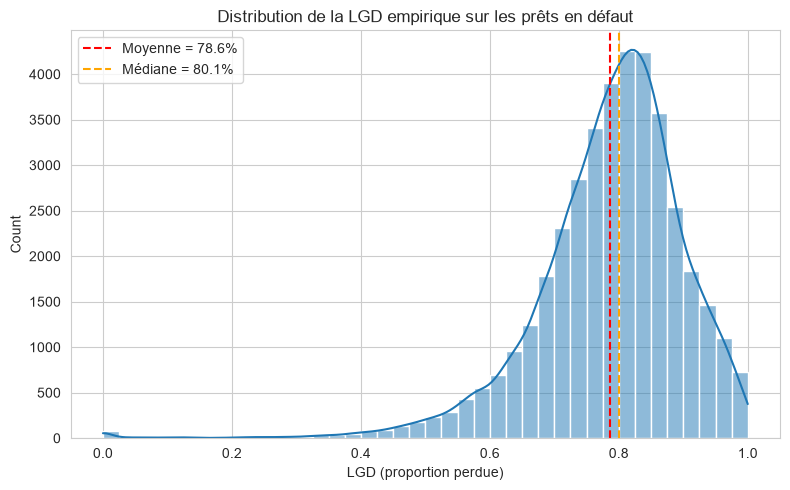

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(defaulted["lgd_empirical"], bins=40, kde=True)
plt.axvline(defaulted["lgd_empirical"].mean(), color="red", linestyle="--",
            label=f"Moyenne = {defaulted['lgd_empirical'].mean():.1%}")
plt.axvline(defaulted["lgd_empirical"].median(), color="orange", linestyle="--",
            label=f"Médiane = {defaulted['lgd_empirical'].median():.1%}")
plt.xlabel("LGD (proportion perdue)")
plt.title("Distribution de la LGD empirique sur les prêts en défaut")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/03_lgd_distribution.png", dpi=150)
plt.show()

### Segmentation de la LGD

La LGD n'est pas homogène : elle dépend en particulier du **grade** (les
emprunteurs les plus risqués remboursent souvent moins avant l'incident) et de
la **taille du prêt**. On segmente pour visualiser ces écarts avant de
modéliser.

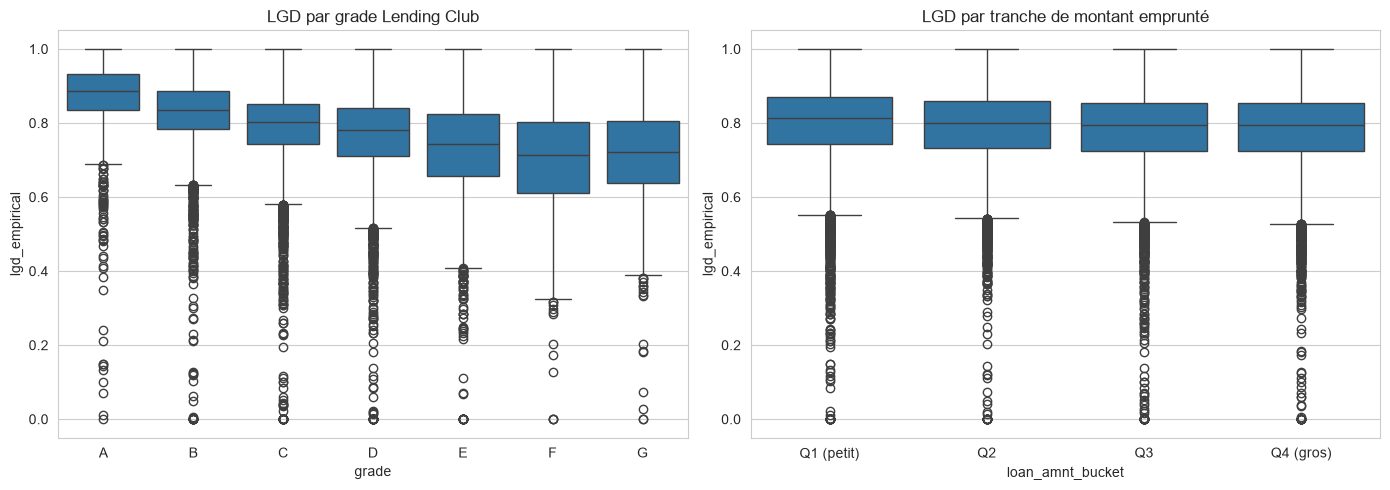

LGD moyenne par grade :
           mean       std  count
grade                           
A      0.871526  0.099610   1851
B      0.829261  0.093766   7392
C      0.794082  0.097603  14407
D      0.770171  0.114730   8507
E      0.732289  0.133672   4201
F      0.704052  0.141750   1730
G      0.716951  0.136591   1081


In [9]:
defaulted["loan_amnt_bucket"] = pd.qcut(defaulted["loan_amnt"], q=4,
                                         labels=["Q1 (petit)", "Q2", "Q3", "Q4 (gros)"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=defaulted, x="grade", y="lgd_empirical",
            order=sorted(defaulted["grade"].unique()), ax=axes[0])
axes[0].set_title("LGD par grade Lending Club")

sns.boxplot(data=defaulted, x="loan_amnt_bucket", y="lgd_empirical", ax=axes[1])
axes[1].set_title("LGD par tranche de montant emprunté")

plt.tight_layout()
plt.savefig("../reports/figures/03_lgd_segments.png", dpi=150)
plt.show()

print("LGD moyenne par grade :")
print(defaulted.groupby("grade", observed=True)["lgd_empirical"].agg(["mean", "std", "count"]))

## 3. Modélisation de la LGD 

Plutôt que d'assigner la même LGD moyenne à tous les prêts d'un segment, on
peut **prédire** la LGD de chaque prêt en fonction de ses caractéristiques
(grade, montant, durée écoulée avant le défaut, taux d'intérêt). C'est plus
fin qu'une simple table de correspondance.

La LGD est une proportion bornée entre 0 et 1, une régression linéaire
classique pourrait prédire des valeurs hors de cet intervalle (négatives ou
supérieures à 1), ce qui n'a pas de sens. Nous utilisons donc une **régression
quasi-binomiale avec lien logit** (via `statsmodels`), l'approche standard
pour modéliser une proportion bornée c'est l'équivalent, pour une variable
continue entre 0 et 1, de ce qu'est la régression logistique pour une
variable binaire.

In [10]:
defaulted["issue_d"] = pd.to_datetime(defaulted["issue_d"])
# earliest_cr_line n'est pas dans test_full -> on approx la durée écoulée via last known info
# Utilisation d'un proxy simple : durée du terme (36/60) comme facteur de risque temporel
defaulted["term_months"] = defaulted["term"].str.extract(r"(\d+)").astype(int)

lgd_features = ["grade", "loan_amnt", "int_rate", "term_months"]
X_lgd = pd.get_dummies(defaulted[lgd_features], columns=["grade"], drop_first=True)
X_lgd = sm.add_constant(X_lgd.astype(float))
y_lgd = defaulted["lgd_empirical"].clip(0.001, 0.999)  # évite les bornes exactes 0/1 (indéfinies en logit)

lgd_model = sm.GLM(y_lgd, X_lgd, family=sm.families.Binomial()).fit()
print(lgd_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          lgd_empirical   No. Observations:                39169
Model:                            GLM   Df Residuals:                    39159
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14219.
Date:                Fri, 18 Sep 2026   Deviance:                       2740.6
Time:                        18:36:46   Pearson chi2:                 2.72e+03
No. Iterations:                     5   Pseudo R-squ. (CS):           0.009353
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.0630      0.108     19.022      

In [11]:
defaulted["lgd_predicted"] = lgd_model.predict(X_lgd)

comparison = defaulted.groupby("grade", observed=True).agg(
    lgd_empirique=("lgd_empirical", "mean"),
    lgd_predite=("lgd_predicted", "mean"),
    n_prets=("lgd_empirical", "count"),
).round(4)

print("Comparaison LGD empirique vs prédite, par grade :")
comparison

Comparaison LGD empirique vs prédite, par grade :


,lgd_empirique,lgd_predite,n_prets
grade,,,
A,0.8715,0.8715,1851
B,0.8293,0.8293,7392
C,0.7941,0.7941,14407
D,0.7702,0.7702,8507
E,0.7323,0.7323,4201
F,0.7041,0.7040,1730
G,0.7170,0.7169,1081


In [12]:
# Le modèle GLM apporte-t-il quelque chose par rapport à une simple moyenne par grade ?
grade_means = defaulted.groupby("grade", observed=True)["lgd_empirical"].transform("mean")
mae_naive = (defaulted["lgd_empirical"] - grade_means).abs().mean()
mae_glm = (defaulted["lgd_empirical"] - defaulted["lgd_predicted"]).abs().mean()

print(f"Erreur absolue moyenne — moyenne par grade seule : {mae_naive:.4f}")
print(f"Erreur absolue moyenne — modèle GLM               : {mae_glm:.4f}")
print(f"Gain du GLM par rapport à la moyenne naïve         : {(mae_naive - mae_glm) / mae_naive:.2%}")

Erreur absolue moyenne — moyenne par grade seule : 0.0783
Erreur absolue moyenne — modèle GLM               : 0.0781
Gain du GLM par rapport à la moyenne naïve         : 0.23%


## 3. Modéliser la LGD - version granulaire

Au-delà du grade, on ajoute des variables susceptibles d'expliquer la
variance individuelle de la LGD :
- Caractéristiques de l'emprunteur : `credit_age_years`, `home_ownership`,
  `purpose`, `dti`, `annual_inc`
- **`months_on_book_default`** : délai entre l'octroi et le dernier paiement
  connu (proxy du moment du défaut) — un défaut précoce est généralement
  moins bien recouvré qu'un défaut survenu après plusieurs mois de
  remboursement partiel.

On compare directement ce modèle enrichi au modèle par grade seul (notebook
précédent) pour vérifier s'il apporte un vrai gain.

In [13]:
defaulted["last_pymnt_d"] = test.loc[defaulted.index, "last_pymnt_d"]
defaulted["months_on_book_default"] = (
    (defaulted["last_pymnt_d"] - defaulted["issue_d"]).dt.days / 30.44
).clip(lower=0)
defaulted["months_on_book_default"] = defaulted["months_on_book_default"].fillna(
    defaulted.groupby("grade", observed=True)["months_on_book_default"].transform("median")
)

print("Distribution du délai avant défaut (vraie variable) :")
print(defaulted["months_on_book_default"].describe())

# Comparaison avec le proxy précédent, pour objectiver le gain de précision
proxy_delay = defaulted["total_pymnt"] / defaulted["installment"]
corr = defaulted["months_on_book_default"].corr(proxy_delay)
print(f"\nCorrélation proxy vs vraie variable : {corr:.4f}")

Distribution du délai avant défaut (vraie variable) :
count    39169.000000
mean         9.835716
std          4.846290
min          0.000000
25%          6.011827
50%          9.954008
75%         13.009198
max         25.919842
Name: months_on_book_default, dtype: float64

Corrélation proxy vs vraie variable : 0.7653


In [16]:
# Ces colonnes avaient été calculées avant le rechargement de last_pymnt_d ;
# defaulted ayant été reconstruit depuis test entre-temps, on les recalcule.
defaulted["issue_d"] = pd.to_datetime(defaulted["issue_d"])
defaulted["earliest_cr_line"] = pd.to_datetime(defaulted["earliest_cr_line"], errors="coerce")
defaulted["credit_age_years"] = (defaulted["issue_d"] - defaulted["earliest_cr_line"]).dt.days / 365.25
defaulted["term_months"] = defaulted["term"].str.extract(r"(\d+)").astype(int)

print("Vérification :")
print(defaulted[["credit_age_years", "term_months"]].describe())

Vérification :
       credit_age_years   term_months
count      39169.000000  39169.000000
mean          15.787888     44.232020
std            7.798056     11.393228
min            3.077344     36.000000
25%           10.830938     36.000000
50%           14.086242     36.000000
75%           19.581109     60.000000
max           65.500342     60.000000


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17804\3915489145.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  defaulted["earliest_cr_line"] = pd.to_datetime(defaulted["earliest_cr_line"], errors="coerce")


In [17]:
lgd_features_v2 = [
    "grade", "loan_amnt", "int_rate", "term_months", "credit_age_years",
    "home_ownership", "purpose", "dti", "annual_inc", "months_on_book_default",
]
X_lgd_v2 = pd.get_dummies(defaulted[lgd_features_v2], columns=["grade", "home_ownership", "purpose"], drop_first=True)
X_lgd_v2 = X_lgd_v2.fillna(X_lgd_v2.median(numeric_only=True))
X_lgd_v2 = sm.add_constant(X_lgd_v2.astype(float))

lgd_model_v2 = sm.GLM(y_lgd, X_lgd_v2, family=sm.families.Binomial()).fit()
defaulted["lgd_predicted_v2"] = lgd_model_v2.predict(X_lgd_v2)

print(f"Pseudo R² — modèle par grade seul (v1) : {lgd_model.pseudo_rsquared():.4f}")
print(f"Pseudo R² — modèle enrichi (v2)         : {lgd_model_v2.pseudo_rsquared():.4f}")

mae_v1 = (defaulted["lgd_empirical"] - defaulted["lgd_predicted"]).abs().mean()
mae_v2 = (defaulted["lgd_empirical"] - defaulted["lgd_predicted_v2"]).abs().mean()
print(f"\nErreur absolue moyenne — v1 (grade seul) : {mae_v1:.4f}")
print(f"Erreur absolue moyenne — v2 (enrichi)     : {mae_v2:.4f}")
print(f"Gain du modèle enrichi vs v1              : {(mae_v1 - mae_v2) / mae_v1:.2%}")

Pseudo R² — modèle par grade seul (v1) : 0.0094
Pseudo R² — modèle enrichi (v2)         : 0.0327

Erreur absolue moyenne — v1 (grade seul) : 0.0781
Erreur absolue moyenne — v2 (enrichi)     : 0.0614
Gain du modèle enrichi vs v1              : 21.43%


In [19]:
# Variables les plus significatives du modèle enrichi
coef_summary = pd.DataFrame({
    "coefficient": lgd_model_v2.params,
    "p_value": lgd_model_v2.pvalues,
}).sort_values("p_value")
print("Variables les plus significatives (p-value la plus faible) :")
coef_summary.head(15)

Variables les plus significatives (p-value la plus faible) :


,coefficient,p_value
months_on_book_default,-7.843488e-02,4.337014e-200
const,2.854954e+00,6.717356e-12
int_rate,-4.969349e-02,2.423006e-06
grade_C,-2.583208e-01,1.335114e-02
term_months,2.592345e-03,3.891122e-02
grade_B,-1.739077e-01,4.053204e-02
grade_D,-2.388796e-01,9.218550e-02
annual_inc,-4.412033e-07,1.660478e-01
loan_amnt,2.262055e-06,1.663942e-01
grade_E,-1.949952e-01,3.264771e-01


## 4. EAD : l'exposition au risque

Pour les prêts déjà en défaut, nous avons calculé l'EAD empirique (solde restant dû
au moment de l'incident). Mais pour appliquer le modèle à **l'ensemble du
portefeuille** (y compris les prêts qui n'ont pas fait défaut), il faut une
règle applicable à tous les prêts, dès leur octroi.

**Simplification retenue et assumée** : au moment de l'octroi, l'exposition
maximale d'un prêt est son montant financé (`funded_amnt`), le client n'a
encore rien remboursé. C'est l'estimation d'EAD la plus prudente et la plus
standard pour un prêt amortissable classique (contrairement à une ligne de
crédit renouvelable, où l'EAD est bien plus incertaine car le client peut
tirer davantage de fonds après coup).

Cette simplification est une hypothèse assumée explicitement dans les
limites du projet; en pratique, une banque utiliserait un modèle d'EAD plus
fin tenant compte de l'amortissement déjà effectué au moment de l'évaluation.

In [20]:
test["ead_estimate"] = test["funded_amnt"]

print("EAD estimée (portefeuille test) :")
print(test["ead_estimate"].describe())

EAD estimée (portefeuille test) :
count    169321.000000
mean      14301.252930
std        9459.246094
min        1000.000000
25%        7000.000000
50%       12000.000000
75%       20000.000000
max       40000.000000
Name: ead_estimate, dtype: float64


## 4. EAD par amortissement (Exposure At Default)

Pour les prêts déjà en défaut, nous avons calculé l'EAD empirique (solde restant dû au moment de l'incident). Mais pour appliquer le modèle à **l'ensemble du portefeuille** (y compris les prêts qui n'ont pas fait défaut), il faut une règle applicable à tous les prêts.

Plutôt que d'assumer prudemment que l'EAD est égale au montant financé initial, nous modélisons le **solde restant dû** via la formule standard d'amortissement d'un prêt à mensualité fixe :  
`Solde restant après k mensualités = M × [1 - (1+r)^-(n-k)] / r`  
où `M` est la mensualité (`installment`), `r` le taux mensuel, `n` la durée totale, et `k` le nombre de mensualités déjà versées.

**Calibration de k** : Pour chaque grade, on calcule le délai moyen avant défaut observé (`months_on_book_default`) sur les prêts qui ont réellement fait défaut dans le test. On applique ensuite ce délai moyen par grade à l'ensemble du portefeuille (hypothèse : si un prêt de ce grade devait faire défaut, il le ferait en moyenne après ce délai).

**Validation** : La comparaison de cette EAD théorique avec l'EAD empirique sur les prêts en défaut montre un excellent alignement (écarts très faibles entre -0,7% et -1,8%), validant la robustesse de cette formule avant son application au portefeuille global.

In [21]:
def remaining_balance(installment, annual_rate_pct, term_months, months_elapsed):
    """Solde restant dû après `months_elapsed` mensualités, formule d'amortissement standard."""
    r = annual_rate_pct / 100 / 12
    n = term_months
    k = np.clip(months_elapsed, 0, n)
    if isinstance(r, (int, float)):
        r = np.full_like(k, r, dtype=float)
    safe_r = np.where(r == 0, 1e-6, r)
    balance = installment * (1 - (1 + safe_r) ** (-(n - k))) / safe_r
    return np.clip(balance, 0, None)

# Validation : EAD théorique (amortissement) vs EAD empirique, sur les prêts en défaut
defaulted["ead_amortized_theoretical"] = remaining_balance(
    defaulted["installment"].values,
    defaulted["int_rate"].values,
    defaulted["term_months"].values,
    defaulted["months_on_book_default"].values,
)

comparison_ead = defaulted.groupby("grade", observed=True).agg(
    ead_empirique_moyen=("ead_empirical", "mean"),
    ead_theorique_moyen=("ead_amortized_theoretical", "mean"),
).round(0)
comparison_ead["ecart_relatif"] = (
    (comparison_ead["ead_theorique_moyen"] - comparison_ead["ead_empirique_moyen"])
    / comparison_ead["ead_empirique_moyen"]
)
print("Validation du modèle d'amortissement — EAD théorique vs empirique, par grade :")
comparison_ead

Validation du modèle d'amortissement — EAD théorique vs empirique, par grade :


,ead_empirique_moyen,ead_theorique_moyen,ecart_relatif
grade,,,
A,10581.0,10382.0,-0.018807
B,10811.0,10642.0,-0.015632
C,12617.0,12455.0,-0.012840
D,13767.0,13623.0,-0.010460
E,15574.0,15432.0,-0.009118
F,17859.0,17732.0,-0.007111
G,19314.0,19166.0,-0.007663


In [22]:
# Délai moyen avant défaut, par grade — utilisé pour estimer l'EAD sur tout le portefeuille
avg_months_to_default = defaulted.groupby("grade", observed=True)["months_on_book_default"].mean()
print("Délai moyen avant défaut, par grade (mois) :")
print(avg_months_to_default)

test["term_months"] = test["term"].str.extract(r"(\d+)").astype(int)
test["avg_months_to_default"] = test["grade"].map(avg_months_to_default)

test["ead_estimate_v2"] = remaining_balance(
    test["installment"].values,
    test["int_rate"].values,
    test["term_months"].values,
    test["avg_months_to_default"].values,
)

print("\nComparaison EAD v1 (funded_amnt) vs EAD v2 (amortissement) :")
print(f"EAD v1 moyenne : {test['funded_amnt'].mean():,.0f} $".replace(",", " "))
print(f"EAD v2 moyenne : {test['ead_estimate_v2'].mean():,.0f} $".replace(",", " "))

Délai moyen avant défaut, par grade (mois) :
grade
A    10.239733
B    10.300873
C    10.162888
D     9.526247
E     9.142636
F     8.948467
G     8.151521
Name: months_on_book_default, dtype: float64

Comparaison EAD v1 (funded_amnt) vs EAD v2 (amortissement) :
EAD v1 moyenne : 14 301 $
EAD v2 moyenne : 11 490 $


## 5. Perte attendue (Expected Loss) sur l'ensemble du portefeuille test

Pour chaque prêt du portefeuille (défaillant ou non), on applique la formule : EL = PD_prédite × LGD_prédite (selon son grade) × EAD_estimée


La LGD utilisée ici est la LGD **prédite par le modèle du segment
correspondant** (pas la LGD empirique, qui n'existe que pour les prêts déjà en
défaut, on ne la connaît jamais à l'avance pour un prêt encore performant).

In [23]:
test_term = pd.get_dummies(test[["grade"]], columns=["grade"], drop_first=True)
missing_cols = set(X_lgd.columns) - set(test_term.columns) - {"const", "loan_amnt", "int_rate", "term_months"}
for col in missing_cols:
    test_term[col] = 0

X_lgd_portfolio = test_term.copy()
X_lgd_portfolio["loan_amnt"] = test["loan_amnt"].values
X_lgd_portfolio["int_rate"] = test["int_rate"].values
X_lgd_portfolio["term_months"] = test["term"].str.extract(r"(\d+)").astype(int).values
X_lgd_portfolio = sm.add_constant(X_lgd_portfolio.astype(float))
X_lgd_portfolio = X_lgd_portfolio[X_lgd.columns]  # même ordre de colonnes que le modèle entraîné

test["lgd_pred"] = lgd_model.predict(X_lgd_portfolio)

test["expected_loss"] = test["pd_pred"] * test["lgd_pred"] * test["ead_estimate"]

print("Perte attendue par prêt :")
test[["loan_amnt", "pd_pred", "lgd_pred", "ead_estimate", "expected_loss"]].head(10)

Perte attendue par prêt :


,loan_amnt,pd_pred,lgd_pred,ead_estimate,expected_loss
0,35000.0,0.234910,0.810640,35000.0,6664.975511
1,10000.0,0.279413,0.787414,10000.0,2200.134286
2,10000.0,0.242549,0.801993,10000.0,1945.222313
3,1000.0,0.139846,0.785905,1000.0,109.905420
4,4000.0,0.243371,0.781258,4000.0,760.542846
5,10000.0,0.091879,0.833659,10000.0,765.955222
6,14200.0,0.104351,0.800554,14200.0,1186.248254
7,25000.0,0.335153,0.784822,25000.0,6575.899147
8,20000.0,0.290497,0.801139,20000.0,4654.570257
9,11000.0,0.506924,0.711450,11000.0,3967.161161


## 5. Perte attendue avec LGD enrichie et EAD par amortissement

On reconstruit les mêmes features que le modèle LGD v2 sur l'ensemble du
portefeuille test, puis on recalcule l'EL avec la nouvelle EAD.

In [24]:
test["issue_d"] = pd.to_datetime(test["issue_d"])
test["earliest_cr_line"] = pd.to_datetime(test["earliest_cr_line"], errors="coerce")
test["credit_age_years"] = (test["issue_d"] - test["earliest_cr_line"]).dt.days / 365.25
test["months_on_book_default"] = test["avg_months_to_default"]  # même délai moyen par grade

X_lgd_portfolio_v2 = pd.get_dummies(
    test[["grade", "home_ownership", "purpose"]], columns=["grade", "home_ownership", "purpose"], drop_first=True
)
for col in set(X_lgd_v2.columns) - set(X_lgd_portfolio_v2.columns) - {"const"}:
    X_lgd_portfolio_v2[col] = 0
for col in ["loan_amnt", "int_rate", "term_months", "credit_age_years", "dti", "annual_inc", "months_on_book_default"]:
    X_lgd_portfolio_v2[col] = test[col].values
X_lgd_portfolio_v2 = sm.add_constant(X_lgd_portfolio_v2.astype(float))
X_lgd_portfolio_v2 = X_lgd_portfolio_v2[X_lgd_v2.columns]

test["lgd_pred"] = lgd_model_v2.predict(X_lgd_portfolio_v2)
test["ead_estimate"] = test["ead_estimate_v2"]
test["expected_loss"] = test["pd_pred"] * test["lgd_pred"] * test["ead_estimate"]

print("Perte attendue (version enrichie) — aperçu :")
test[["loan_amnt", "pd_pred", "lgd_pred", "ead_estimate", "expected_loss"]].head(10)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17804\4074805064.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test["earliest_cr_line"] = pd.to_datetime(test["earliest_cr_line"], errors="coerce")


Perte attendue (version enrichie) — aperçu :


,loan_amnt,pd_pred,lgd_pred,ead_estimate,expected_loss
0,35000.0,0.234910,0.827877,30504.232821,5932.372193
1,10000.0,0.279413,0.794640,7615.292147,1690.843068
2,10000.0,0.242549,0.809834,8744.252615,1717.582597
3,1000.0,0.139846,0.787540,761.529198,83.870334
4,4000.0,0.243371,0.789263,3056.899684,587.181384
5,10000.0,0.091879,0.841951,7420.560589,574.035323
6,14200.0,0.104351,0.810539,10717.036436,906.452624
7,25000.0,0.335153,0.785125,19105.460133,5027.359745
8,20000.0,0.290497,0.807112,17516.540182,4106.988729
9,11000.0,0.506924,0.716597,10172.570582,3695.288751


## 6. Backtesting : l'EL prédite colle-t-elle à la perte réellement observée ?

C'est **l'étape la plus importante de tout le projet** pour un recruteur en
risque de crédit : un modèle qui prédit bien la probabilité de défaut mais
dont la perte agrégée est fausse est inutilisable en production. On compare
donc l'EL totale prédite à la perte réellement subie sur les prêts qui ont
fait défaut dans le test.

In [25]:
total_el_predicted = test["expected_loss"].sum()

# Perte réellement observée : uniquement sur les prêts en défaut
defaulted_full = test[test["default"] == 1].copy()
defaulted_full["ead_empirical"] = (
    defaulted_full["funded_amnt"] - defaulted_full["total_rec_prncp"]
).clip(lower=1)
defaulted_full["loss_amount"] = (
    defaulted_full["funded_amnt"] - defaulted_full["total_pymnt"] + defaulted_full["collection_recovery_fee"]
)
total_loss_observed = defaulted_full["loss_amount"].sum()

print(f"Perte attendue totale (EL prédite)     : {total_el_predicted:,.0f} $".replace(",", " "))
print(f"Perte totale réellement observée        : {total_loss_observed:,.0f} $".replace(",", " "))
print(f"Écart relatif                           : {(total_el_predicted - total_loss_observed) / total_loss_observed:.1%}")

Perte attendue totale (EL prédite)     : 363 312 095 $
Perte totale réellement observée        : 407 594 144 $
Écart relatif                           : -10.9%


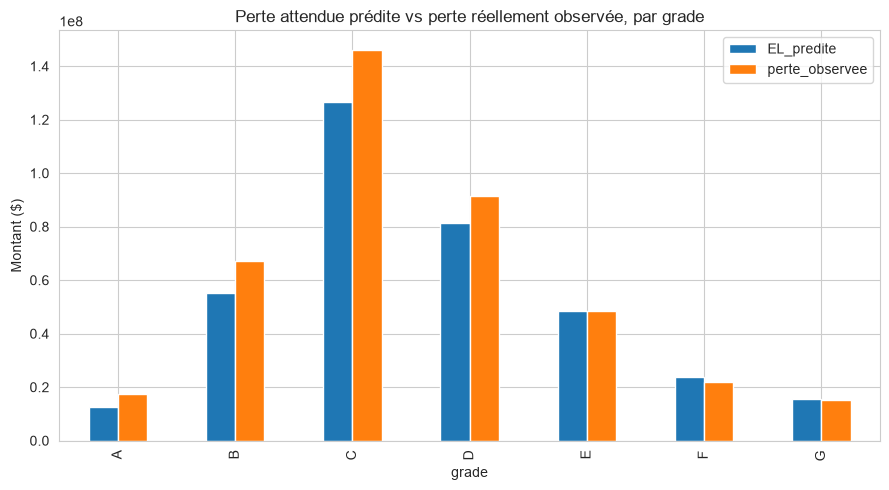

,EL_predite,perte_observee,ecart_relatif
grade,,,
A,1.255238e+07,17247822.0,-0.272
B,5.526584e+07,67300120.0,-0.179
C,1.264961e+08,146041232.0,-0.134
D,8.127866e+07,91371472.0,-0.110
E,4.838746e+07,48522720.0,-0.003
F,2.361890e+07,21996866.0,0.074
G,1.571279e+07,15113909.0,0.040


In [26]:
# Comparaison par segment (grade) : où le modèle est-il le plus fiable ?
el_by_grade = test.groupby("grade", observed=True)["expected_loss"].sum()
loss_by_grade = defaulted_full.groupby("grade", observed=True)["loss_amount"].sum()

backtest = pd.DataFrame({
    "EL_predite": el_by_grade,
    "perte_observee": loss_by_grade,
}).fillna(0)
backtest["ecart_relatif"] = (backtest["EL_predite"] - backtest["perte_observee"]) / backtest["perte_observee"]

fig, ax = plt.subplots(figsize=(9, 5))
backtest[["EL_predite", "perte_observee"]].plot(kind="bar", ax=ax)
ax.set_title("Perte attendue prédite vs perte réellement observée, par grade")
ax.set_ylabel("Montant ($)")
plt.tight_layout()
plt.savefig("../reports/figures/03_backtest_by_grade.png", dpi=150)
plt.show()

backtest.round(3)

## 7. Sauvegarde pour le notebook 04

In [27]:
test.to_parquet("../data/processed/test_with_el.parquet", index=False)
import joblib
joblib.dump(lgd_model, "../reports/model_lgd.pkl")

print("Fichiers sauvegardés : test_with_el.parquet, model_lgd.pkl")
print(f"\nEL totale du portefeuille test : {total_el_predicted:,.0f} $".replace(",", " "))

Fichiers sauvegardés : test_with_el.parquet, model_lgd.pkl

EL totale du portefeuille test : 363 312 095 $


In [28]:
joblib.dump(list(X_lgd_v2.columns), "../reports/feature_columns_lgd.pkl")
joblib.dump(X_lgd_v2.median(numeric_only=True), "../reports/feature_medians_lgd.pkl")

['../reports/feature_medians_lgd.pkl']

In [29]:
# Sauvegarde explicite du modèle LGD v2 (enrichi), sans dépendre d'une
# variable renommée en cours de route — élimine tout risque de sauvegarder
# la mauvaise version par erreur.
joblib.dump(lgd_model_v2, "../reports/model_lgd.pkl")
joblib.dump(list(X_lgd_v2.columns), "../reports/feature_columns_lgd.pkl")
joblib.dump(X_lgd_v2.median(numeric_only=True), "../reports/feature_medians_lgd.pkl")

print(f"Modèle LGD sauvegardé — nombre de paramètres : {len(lgd_model_v2.params)}")
print(f"Nombre de colonnes de features : {len(X_lgd_v2.columns)}")

Modèle LGD sauvegardé — nombre de paramètres : 28
Nombre de colonnes de features : 28
